# 02 — Detection Analysis

Runs the `Detector` module (class-agnostic object localization) in isolation and inspects its output.

Covered in this notebook:

1. Load config and instantiate `Detector` (backend-agnostic — works with `mock_contour` or `rf_detr`)
2. Load a sample image into `ImageData`
3. Run detection and visualize predicted bounding boxes
4. Compare backends (`mock_contour` vs `rf_detr`) on the same image
5. Confidence-score distribution across the benchmark set
6. Compare predictions against benchmark ground truth (IoU)
7. Run `Cropper` on the detections and inspect the two crop resolutions (`image_array` vs `raw_image_array`)

> Note: the `rf_detr` backend requires `checkpoint_best_ema.pth` under `weights/detector/` and, ideally, a CUDA GPU. If weights are not available, switch `detection.backend` to `mock_contour` in the cells below — no download required.


## 1. Environment setup

In [7]:
import os, sys
import time
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")
assert (PROJECT_ROOT / "configs" / "config.yaml").is_file()

Project root: g:\VsCode\Python\DACN\stocktaking_ai_mini


In [8]:
import json
import random

import cv2
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.core.config import load_config
from src.detection.detector import Detector
from src.detection.cropper import Cropper
from src.models.models import BoundingBox, ImageData, RefinementResult

pd.set_option("display.max_colwidth", 80)
%matplotlib inline

## 2. Config and helper functions

`Detector` and `Cropper` never load images from disk themselves — that responsibility belongs to the caller (Detector.detect only takes an already-loaded `ImageData`). We add a small local helper to build one from a file path.

In [9]:
config = load_config()

print(f"Configured detection backend: {config.detection.backend}")
print(f"Confidence threshold:         {config.detection.confidence_threshold}")
print(f"Max detections:                {config.detection.max_detections}")

Configured detection backend: rf_detr
Confidence threshold:         0.35
Max detections:                50


In [10]:
def load_image_data(image_path: Path) -> ImageData:
    """Loads an image file from disk into an ImageData DTO (BGR, HxWx3)."""
    image_array = cv2.imread(str(image_path))
    if image_array is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")
    height, width = image_array.shape[:2]
    return ImageData(
        image_id=image_path.stem,
        source_path=str(image_path),
        image_array=image_array,
        width=width,
        height=height,
    )


def show_image_bgr(ax, image_array_bgr: np.ndarray, title: str = ""):
    ax.imshow(cv2.cvtColor(image_array_bgr, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=10)
    ax.axis("off")


def draw_detections(ax, detections, color="lime", show_confidence=True):
    for det in detections:
        box = det.bbox
        rect = patches.Rectangle(
            (box.x1, box.y1), box.width, box.height,
            linewidth=2, edgecolor=color, facecolor="none",
        )
        ax.add_patch(rect)
        if show_confidence:
            ax.text(box.x1, max(0, box.y1 - 5), f"{det.confidence:.2f}",
                     color=color, fontsize=8, weight="bold")

## 3. Pick a sample image

Use a benchmark image if available (so we also have ground truth to compare against later), otherwise fall back to `data/query/`.

In [11]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

benchmark_images_dir = config.resolve_path(config.paths.benchmark_images_dir)
query_dir = config.resolve_path(config.paths.query_dir)

candidate_dir = benchmark_images_dir if benchmark_images_dir.exists() and any(
    benchmark_images_dir.iterdir()
) else query_dir

available_images = sorted([f for f in candidate_dir.iterdir() if f.suffix.lower() in IMAGE_EXTS])
print(f"Using image source: {candidate_dir}")
print(f"Found {len(available_images)} image(s)")

assert available_images, f"No images found in {candidate_dir}"
sample_path = random.choice(available_images)
print(f"Sample image: {sample_path.name}")

Using image source: G:\VsCode\Python\DACN\stocktaking_ai_mini\data\benchmark\images
Found 31 image(s)
Sample image: IMG_0577_jpg.rf.L0LklW4w1VkFn4h5Bqwe.jpg


## 4. Run the Detector

In [12]:
detector = Detector(config)
image_data = load_image_data(sample_path)

start = time.perf_counter()
detection_result = detector.detect(image_data)
elapsed_ms = (time.perf_counter() - start) * 1000

print(f"Backend:            {config.detection.backend}")
print(f"Detections found:   {len(detection_result.detections)}")
print(f"Reported latency:   {detection_result.processing_time_ms:.2f} ms")
print(f"Wall-clock latency: {elapsed_ms:.2f} ms")

2026-09-03 17:41:10 | INFO     | src.detection.backends.rf_detr | Loading RF-DETR model class='RFDETRBase' kwargs={'pretrain_weights': 'weights/detector/checkpoint_best_ema.pth'}


[2026-09-03 17:41:10] [WARNING] rf-detr - Checkpoint has 1 classes but model is configured for 90. Using checkpoint class count (1). Pass num_classes=1 to suppress this warning.
[2026-09-03 17:41:10] [WARNING] rf-detr - load_pretrain_weights: args.num_queries absent; inferred ckpt_num_queries=300 from tensor rows 3900 ÷ ckpt_group_detr=13.


2026-09-03 17:41:10 | INFO     | src.detection.backends.rf_detr | Optimizing RF-DETR for inference (dtype=float32 compile=False batch_size=1)
2026-09-03 17:41:11 | INFO     | src.detection.backends.rf_detr | RfDetrBackend initialized (variant='base' weights_path='weights/detector/checkpoint_best_ema.pth')
2026-09-03 17:41:11 | INFO     | src.detection.detector | Detector initialized with backend='rf_detr'
2026-09-03 17:41:14 | INFO     | src.detection.detector | Detector found 12 region(s) in image_id='IMG_0577_jpg.rf.L0LklW4w1VkFn4h5Bqwe' (3225.67 ms)
Backend:            rf_detr
Detections found:   12
Reported latency:   3225.67 ms
Wall-clock latency: 3248.40 ms


In [13]:
det_df = pd.DataFrame([
    {
        "index": i,
        "confidence": det.confidence,
        "class_name": det.class_name,
        "x1": det.bbox.x1, "y1": det.bbox.y1, "x2": det.bbox.x2, "y2": det.bbox.y2,
        "width": det.bbox.width, "height": det.bbox.height,
        "area_ratio": det.bbox.area / (image_data.width * image_data.height),
    }
    for i, det in enumerate(detection_result.detections)
])
det_df

,index,confidence,class_name,x1,y1,x2,y2,width,height,area_ratio
0,0,0.973651,object,138.099625,642.037415,1436.091431,1683.051636,1297.991806,1041.014221,0.110822
1,1,0.969807,object,1426.051025,0.000000,2822.096680,1752.771606,1396.045654,1752.771606,0.200689
2,2,0.965321,object,313.382812,1728.240112,1272.345459,2976.670410,958.962646,1248.430298,0.098189
3,3,0.964177,object,2783.432129,2023.343262,3744.948730,2950.892578,961.516602,927.549316,0.073146
4,4,0.962824,object,1111.134888,1498.490356,2312.362549,2544.416992,1201.227661,1045.926636,0.103044
5,5,0.949313,object,2440.390137,1243.041382,3480.396240,2396.884521,1040.006104,1153.843140,0.098419
6,6,0.943704,object,2259.700928,0.000000,3299.869873,890.961792,1040.168945,890.961792,0.076008
7,7,0.942894,object,966.438416,1119.501465,1953.242798,2203.770264,986.804382,1084.268799,0.087754
8,8,0.934432,object,1495.959229,2456.572998,2657.290527,2984.149170,1161.331299,527.576172,0.050250
9,9,0.934210,object,1084.546875,340.690857,1564.286011,1429.724121,479.739136,1089.033264,0.042849


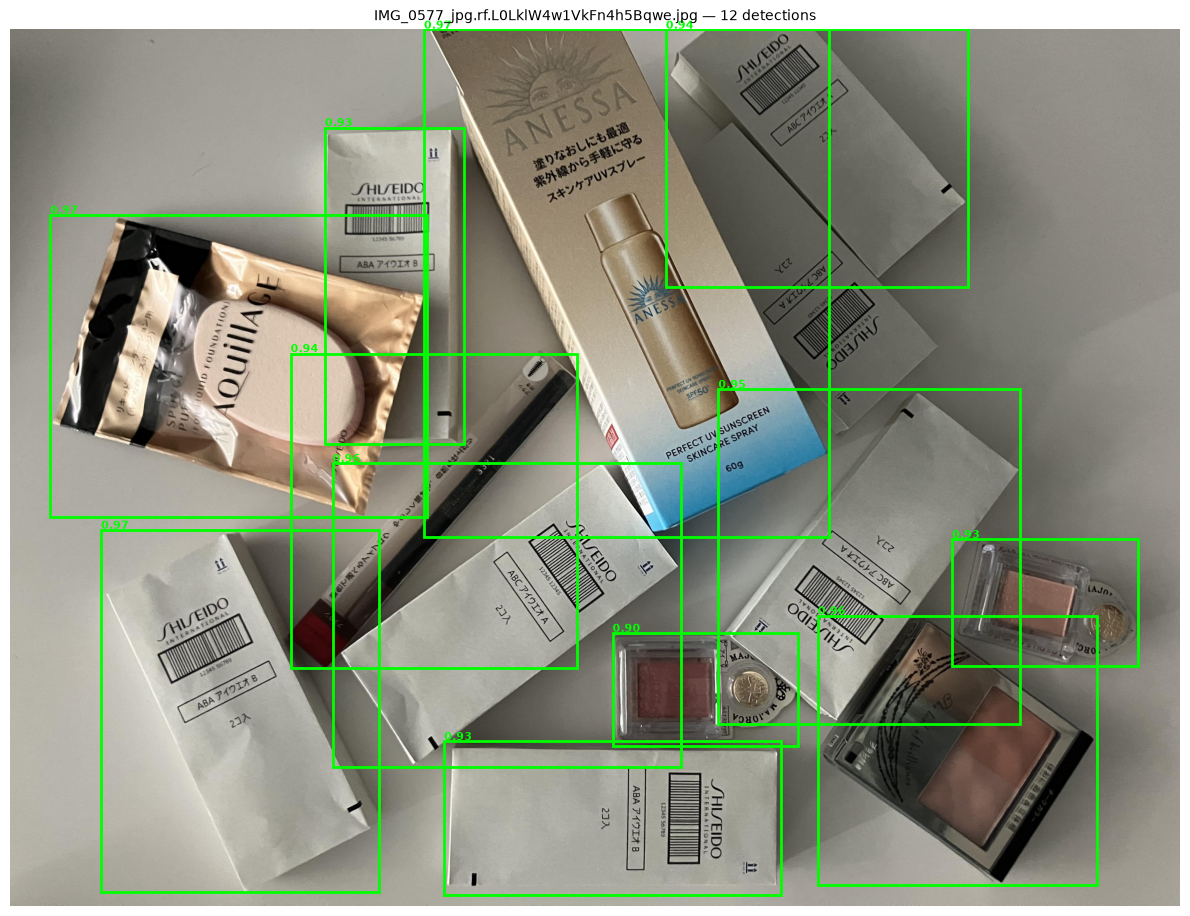

In [14]:
fig, ax = plt.subplots(figsize=(12, 12))
show_image_bgr(ax, image_data.image_array, title=f"{sample_path.name} — {len(detection_result.detections)} detections")
draw_detections(ax, detection_result.detections)
plt.tight_layout()
plt.show()

## 5. Backend comparison

Build a second `Detector` on an overridden config copy (`AppConfig.model_copy`, the same pattern `InventoryPipeline._resolve_decision_components` uses for per-call overrides) and compare against the primary backend on the same image.

2026-09-03 17:41:17 | INFO     | src.detection.backends.mock_contour | MockContourBackend initialized (canny_t1=40 canny_t2=120 blur_kernel=5)
2026-09-03 17:41:17 | INFO     | src.detection.detector | Detector initialized with backend='mock_contour'
2026-09-03 17:41:17 | INFO     | src.detection.detector | Detector found 13 region(s) in image_id='IMG_0577_jpg.rf.L0LklW4w1VkFn4h5Bqwe' (55.17 ms)


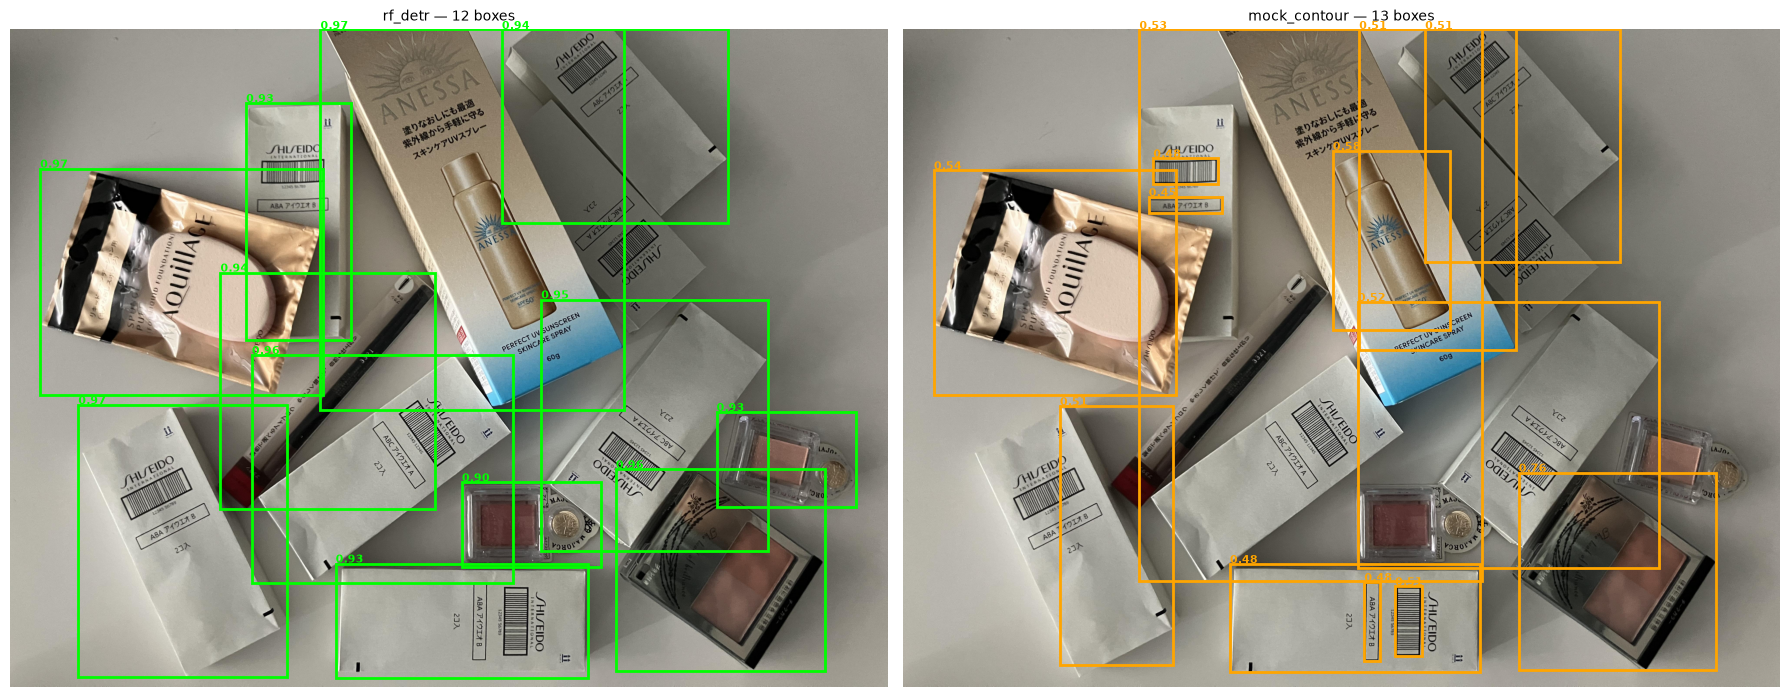

In [15]:
OTHER_BACKEND = "mock_contour" if config.detection.backend == "rf_detr" else "rf_detr"

try:
    other_detection_config = config.detection.model_copy(update={"backend": OTHER_BACKEND})
    other_config = config.model_copy(update={"detection": other_detection_config})
    other_detector = Detector(other_config)
    other_result = other_detector.detect(image_data)

    fig, axes = plt.subplots(1, 2, figsize=(18, 9))
    show_image_bgr(axes[0], image_data.image_array,
                    title=f"{config.detection.backend} — {len(detection_result.detections)} boxes")
    draw_detections(axes[0], detection_result.detections, color="lime")

    show_image_bgr(axes[1], image_data.image_array,
                    title=f"{OTHER_BACKEND} — {len(other_result.detections)} boxes")
    draw_detections(axes[1], other_result.detections, color="orange")
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print(f"Could not load '{OTHER_BACKEND}' backend (likely missing weights/dependencies): {exc}")

## 6. Confidence-score distribution across multiple images

Run detection over a small batch to see how confidence scores and detection counts vary.

In [16]:
SAMPLE_SIZE = min(10, len(available_images))
batch_paths = random.sample(available_images, k=SAMPLE_SIZE)

all_confidences = []
counts_per_image = []

for path in batch_paths:
    img = load_image_data(path)
    result = detector.detect(img)
    counts_per_image.append({"image": path.name, "num_detections": len(result.detections)})
    all_confidences.extend([d.confidence for d in result.detections])

counts_df = pd.DataFrame(counts_per_image)
display(counts_df)

print(f"Total detections across {SAMPLE_SIZE} image(s): {len(all_confidences)}")
if all_confidences:
    print(pd.Series(all_confidences, name="confidence").describe())

2026-09-03 17:41:21 | INFO     | src.detection.detector | Detector found 6 region(s) in image_id='IMG_0582_jpg.rf.bxAKHhwmpqgu20kL8npR' (447.63 ms)
2026-09-03 17:41:21 | INFO     | src.detection.detector | Detector found 13 region(s) in image_id='IMG_0578_jpg.rf.oPsBmrQrOFfXvlzydeX4' (224.62 ms)
2026-09-03 17:41:21 | INFO     | src.detection.detector | Detector found 14 region(s) in image_id='IMG_0576_jpg.rf.TKCf2iUHOUcgOPKyc8qP' (221.47 ms)
2026-09-03 17:41:22 | INFO     | src.detection.detector | Detector found 14 region(s) in image_id='IMG_0579_jpg.rf.yowq0fDPnqwaYtLv6B8z' (228.88 ms)
2026-09-03 17:41:24 | INFO     | src.detection.detector | Detector found 9 region(s) in image_id='7_jpg.rf.oQ4WxRz7iWKzjAEX7gd9' (2079.48 ms)
2026-09-03 17:41:27 | INFO     | src.detection.detector | Detector found 7 region(s) in image_id='IMG_0569_jpg.rf.cDK0vyv3sXtlEyBdiQPz' (338.43 ms)
2026-09-03 17:41:28 | INFO     | src.detection.detector | Detector found 7 region(s) in image_id='IMG_0567_jpg.rf.m

,image,num_detections
0,IMG_0582_jpg.rf.bxAKHhwmpqgu20kL8npR.jpg,6
1,IMG_0578_jpg.rf.oPsBmrQrOFfXvlzydeX4.jpg,13
2,IMG_0576_jpg.rf.TKCf2iUHOUcgOPKyc8qP.jpg,14
3,IMG_0579_jpg.rf.yowq0fDPnqwaYtLv6B8z.jpg,14
4,7_jpg.rf.oQ4WxRz7iWKzjAEX7gd9.jpg,9
5,IMG_0569_jpg.rf.cDK0vyv3sXtlEyBdiQPz.jpg,7
6,IMG_0567_jpg.rf.mIjCPwdMT96DoTo4LlkZ.jpg,7
7,IMG_0585_jpg.rf.HCnXlWzg3J5bck8QWMUr.jpg,12
8,6_jpg.rf.fsTWp5Ex5KXGN11ElAye.jpg,12
9,10_jpg.rf.Rw9wcbvuQ0aoboUqZYfI.jpg,9


Total detections across 10 image(s): 103
count    103.000000
mean       0.887131
std        0.150057
min        0.356027
25%        0.903258
50%        0.948036
75%        0.961835
max        0.978735
Name: confidence, dtype: float64


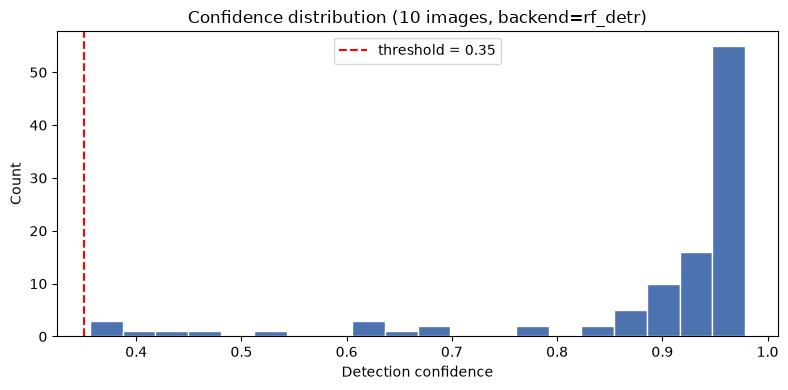

In [17]:
if all_confidences:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(all_confidences, bins=20, color="#4C72B0", edgecolor="white")
    ax.axvline(config.detection.confidence_threshold, color="red", linestyle="--",
               label=f"threshold = {config.detection.confidence_threshold}")
    ax.set_xlabel("Detection confidence")
    ax.set_ylabel("Count")
    ax.set_title(f"Confidence distribution ({SAMPLE_SIZE} images, backend={config.detection.backend})")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 7. Compare against benchmark ground truth (IoU)

Only meaningful when the sample image came from `data/benchmark/images/` and has COCO annotations. Matches each ground-truth box to its best-IoU prediction using `BoundingBox.iou()`.

In [18]:
benchmark_labels_path = config.resolve_path(config.paths.benchmark_labels_dir)
coco = None
if benchmark_labels_path.is_file():
    with open(benchmark_labels_path, "r", encoding="utf-8") as f:
        coco = json.load(f)

gt_boxes = []
if coco is not None:
    image_meta = next((im for im in coco["images"] if im["file_name"] == sample_path.name), None)
    if image_meta is not None:
        anns = [a for a in coco["annotations"] if a["image_id"] == image_meta["id"]]
        for ann in anns:
            x, y, w, h = ann["bbox"]
            gt_boxes.append(BoundingBox(x1=x, y1=y, x2=x + w, y2=y + h))

print(f"Ground-truth boxes for this image: {len(gt_boxes)}")

Ground-truth boxes for this image: 13


In [19]:
IOU_MATCH_THRESHOLD = config.validation.iou_match_threshold

matches = []
pred_boxes = [d.bbox for d in detection_result.detections]
matched_pred_indices = set()

for gt_idx, gt_box in enumerate(gt_boxes):
    best_iou, best_pred_idx = 0.0, None
    for pred_idx, pred_box in enumerate(pred_boxes):
        if pred_idx in matched_pred_indices:
            continue
        iou = gt_box.iou(pred_box)
        if iou > best_iou:
            best_iou, best_pred_idx = iou, pred_idx
    is_match = best_iou >= IOU_MATCH_THRESHOLD
    if is_match:
        matched_pred_indices.add(best_pred_idx)
    matches.append({"gt_index": gt_idx, "best_iou": round(best_iou, 3), "matched": is_match})

if gt_boxes:
    match_df = pd.DataFrame(matches)
    display(match_df)

    true_positives = match_df["matched"].sum()
    false_negatives = len(gt_boxes) - true_positives
    false_positives = len(pred_boxes) - len(matched_pred_indices)
    precision = true_positives / len(pred_boxes) if pred_boxes else 0.0
    recall = true_positives / len(gt_boxes) if gt_boxes else 0.0

    print(f"IoU match threshold: {IOU_MATCH_THRESHOLD}")
    print(f"True positives:  {true_positives}")
    print(f"False negatives: {false_negatives}")
    print(f"False positives: {false_positives}")
    print(f"Precision:       {precision:.3f}")
    print(f"Recall:          {recall:.3f}")
else:
    print("No ground truth available for this image — skip, or re-run cell 3 to pick a benchmark image.")

,gt_index,best_iou,matched
0,0,0.983,True
1,1,0.979,True
2,2,0.932,True
3,3,0.942,True
4,4,0.976,True
5,5,0.945,True
6,6,0.966,True
7,7,0.950,True
8,8,0.956,True
9,9,0.942,True


IoU match threshold: 0.3
True positives:  12
False negatives: 1
False positives: 0
Precision:       1.000
Recall:          0.923


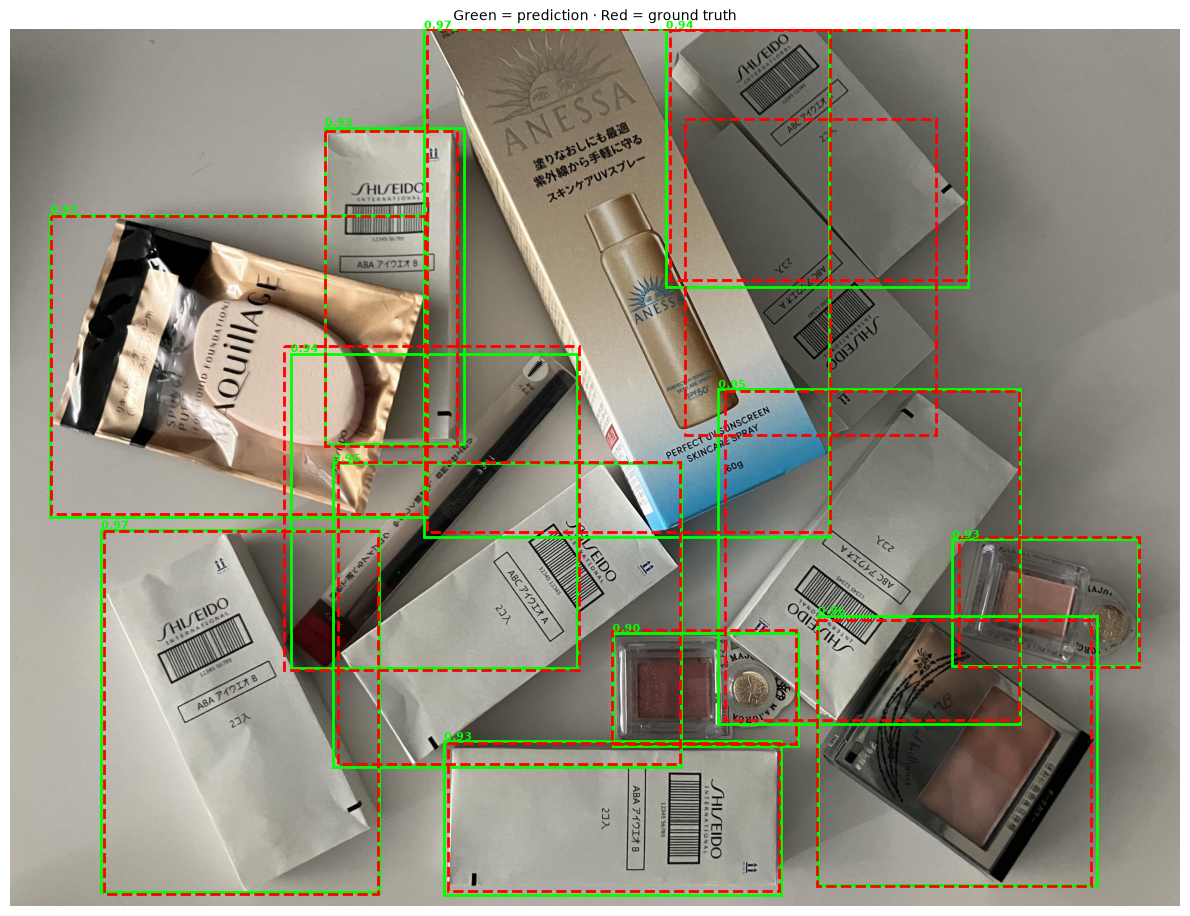

In [20]:
if gt_boxes:
    fig, ax = plt.subplots(figsize=(12, 12))
    show_image_bgr(ax, image_data.image_array, title="Green = prediction · Red = ground truth")
    draw_detections(ax, detection_result.detections, color="lime")
    for gt_box in gt_boxes:
        rect = patches.Rectangle(
            (gt_box.x1, gt_box.y1), gt_box.width, gt_box.height,
            linewidth=2, edgecolor="red", linestyle="--", facecolor="none",
        )
        ax.add_patch(rect)
    plt.tight_layout()
    plt.show()

## 8. Run the Cropper

`Cropper.crop()` requires a `RefinementResult` even when segmentation refinement did not run — pass an untriggered one so every crop falls back to the raw detector bbox.

In [21]:
empty_refinement = RefinementResult(image_id=image_data.image_id, triggered=False, backend="none")

cropper = Cropper(config)
crops = cropper.crop(image_data, detection_result, empty_refinement)

print(f"Crops produced: {len(crops)}")
print(f"Target size (retrieval input): {config.cropping.target_size}")
print(f"Padding: {config.cropping.padding_pixels}px")

2026-09-03 17:41:32 | INFO     | src.detection.cropper | Cropper initialized with padding=4px target_size=(1024, 1024) use_refined_bbox=True
2026-09-03 17:41:32 | INFO     | src.detection.cropper | Cropper produced 12 crop(s) for image_id='IMG_0577_jpg.rf.L0LklW4w1VkFn4h5Bqwe' (27.62 ms)
Crops produced: 12
Target size (retrieval input): [1024, 1024]
Padding: 4px


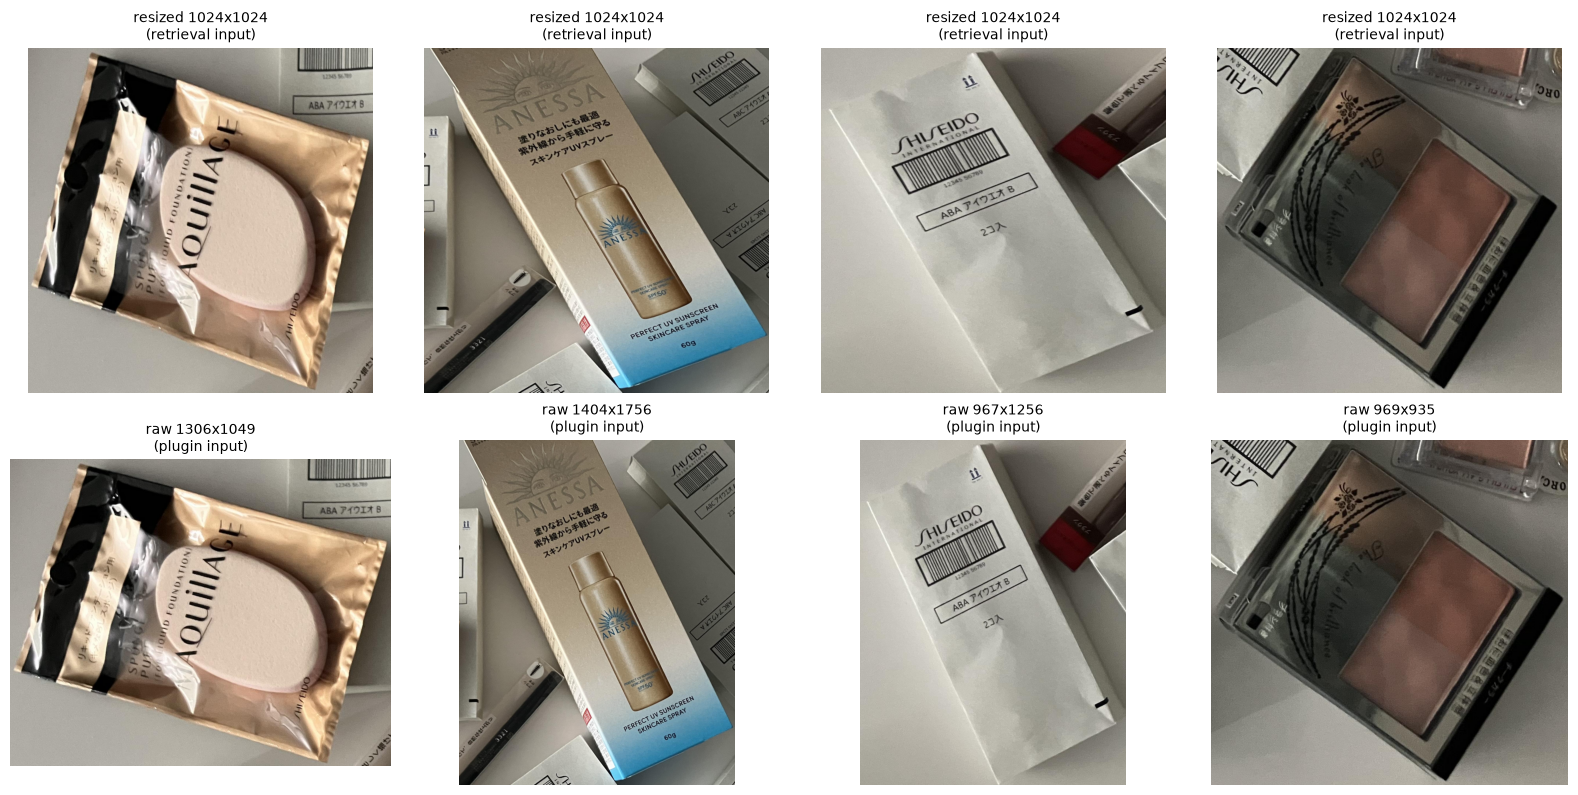

In [22]:
N_SAMPLES = min(4, len(crops))
sample_crops = crops[:N_SAMPLES]

if sample_crops:
    fig, axes = plt.subplots(2, N_SAMPLES, figsize=(4 * N_SAMPLES, 8))
    if N_SAMPLES == 1:
        axes = axes.reshape(2, 1)
    for i, crop in enumerate(sample_crops):
        show_image_bgr(axes[0, i], crop.image_array,
                        title=f"resized {crop.image_array.shape[1]}x{crop.image_array.shape[0]}\n(retrieval input)")
        show_image_bgr(axes[1, i], crop.raw_image_array,
                        title=f"raw {crop.raw_image_array.shape[1]}x{crop.raw_image_array.shape[0]}\n(plugin input)")
    plt.tight_layout()
    plt.show()
else:
    print("No crops to display.")

## 9. Summary

In [23]:
summary = {
    "Backend": config.detection.backend,
    "Confidence threshold": config.detection.confidence_threshold,
    "Detections (sample image)": len(detection_result.detections),
    "Crops produced": len(crops),
    "Ground-truth boxes (sample image)": len(gt_boxes),
}
pd.DataFrame([summary]).T.rename(columns={0: "Value"})

,Value
Backend,rf_detr
Confidence threshold,0.35
Detections (sample image),12
Crops produced,12
Ground-truth boxes (sample image),13


---
**Quick observations (fill in after running on real data):**

- Does the confidence histogram suggest the current `confidence_threshold` (0.35) is well-calibrated, or is it cutting off too many/too few detections?
- Do `mock_contour` and `rf_detr` disagree meaningfully on this image? On which kinds of regions?
- How does precision/recall on this single sample compare to the aggregate numbers in the README (P=0.970, R=0.940, mAP@50=0.990)? Run over more images before drawing conclusions.
- Does the raw (non-resized) crop resolution look sufficient for OCR/barcode plugins downstream?

**Next notebook:** `03_overlap_segmentation.ipynb` — analyze `OverlapResolver` and SAM2 boundary refinement on the overlap groups found here.
